In [69]:
import torch
import os
from glob import glob
import h5py
import re
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [22]:
# Use glob to get a list of all files
files = glob('../results/tarp_posterior_hmc_exhaustive_*')

# Create a dictionary to hold your parsed data
experiments = {}

# Parse each filename
for path in files:
    filename = os.path.split(path)[-1]
    # Use regex to parse parameters
    matches = re.search(
        # TODO add a grid id to better read the experiment
        r'tarp_posterior_hmc_exhaustive_(\d+)_mass([0-9.]+(?:e-?[0-9]+)?)_leapfrog(\d+)_M(\d+)_tmin([0-9.]+(?:e-?[0-9]+)?)_snr([0-9.]+(?:e-?[0-9]+)?)',
        filename)
    if matches:
        # Create a dictionary to store parameters for this experiment
        experiment = {
            'id': int(matches.group(1)), # will be replaced by grid id, now this id is the posterior id for a specific experiment
            'mass': float(matches.group(2)),
            'leapfrog_steps': int(matches.group(3)),
            'M': int(matches.group(4)),
            'corrector_tmin': float(matches.group(5)),
            'snr': float(matches.group(6)),
        }

        # Add this experiment to the main dictionary, using the id as the key
        experiments[experiment['id']] = experiment

# Now experiments is a dictionary of your parsed data, indexed by experiment id


In [116]:
files

['../results/tarp_posterior_hmc_exhaustive_10_mass1_leapfrog2_M3_tmin0.5_snr1e-2_2.h5',
 '../results/tarp_posterior_hmc_exhaustive_3_mass1_leapfrog5_M1_tmin0.5_snr1e-2_2.h5',
 '../results/tarp_posterior_hmc_exhaustive_2_mass1_leapfrog2_M1_tmin0.1_snr1e-2_1.h5',
 '../results/tarp_posterior_hmc_exhaustive_5_mass1_leapfrog2_M3_tmin0.1_snr1e-2_2.h5',
 '../results/tarp_posterior_hmc_exhaustive_4_mass1_leapfrog5_M3_tmin0.5_snr1e-2_1.h5',
 '../results/tarp_posterior_hmc_exhaustive_8_mass1_leapfrog5_M3_tmin0.5_snr1e-2_2.h5',
 '../results/tarp_posterior_hmc_exhaustive_9_mass1_leapfrog2_M3_tmin0.1_snr1e-2_1.h5',
 '../results/tarp_posterior_hmc_exhaustive_6_mass1_leapfrog2_M1_tmin0.5_snr1e-2_2.h5',
 '../results/tarp_posterior_hmc_exhaustive_7_mass1_leapfrog5_M1_tmin0.1_snr1e-2_1.h5',
 '../results/tarp_posterior_hmc_exhaustive_1_mass1_leapfrog2_M3_tmin0.5_snr1e-2_1.h5',
 '../results/tarp_posterior_hmc_exhaustive_10_mass1_leapfrog2_M3_tmin0.1_snr1e-2_1.h5',
 '../results/tarp_posterior_hmc_exhaustiv

In [138]:
good_files = []
for f in files:
    try:
        data = h5py.File(f)
        if data["model"][:].max() > 0:
            good_files.append(f)
    except:
        pass

In [150]:
good_files

['../results/tarp_posterior_hmc_exhaustive_2_mass1_leapfrog2_M1_tmin0.1_snr1e-2_1.h5',
 '../results/tarp_posterior_hmc_exhaustive_2_mass1_leapfrog2_M1_tmin0.5_snr1e-2_2.h5',
 '../results/tarp_posterior_hmc_exhaustive_6_mass1_leapfrog2_M1_tmin0.1_snr1e-2_1.h5',
 '../results/tarp_posterior_hmc_exhaustive_2_mass1_leapfrog2_M1_tmin0.1_snr1e-2_2.h5',
 '../results/tarp_posterior_hmc_exhaustive_2_mass1_leapfrog2_M1_tmin0.5_snr1e-2_1.h5',
 '../results/tarp_posterior_hmc_exhaustive_6_mass1_leapfrog2_M1_tmin0.1_snr1e-2_2.h5',
 '../results/tarp_posterior_hmc_exhaustive_3_mass1_leapfrog2_M1_tmin0.1_snr1e-2_2.h5',
 '../results/tarp_posterior_hmc_exhaustive_3_mass1_leapfrog2_M1_tmin0.5_snr1e-2_1.h5',
 '../results/tarp_posterior_hmc_exhaustive_7_mass1_leapfrog2_M1_tmin0.1_snr1e-2_2.h5',
 '../results/tarp_posterior_hmc_exhaustive_3_mass1_leapfrog2_M1_tmin0.1_snr1e-2_1.h5',
 '../results/tarp_posterior_hmc_exhaustive_3_mass1_leapfrog2_M1_tmin0.5_snr1e-2_2.h5',
 '../results/tarp_posterior_hmc_exhaustive_

In [175]:
data = h5py.File(good_files[25])

(-0.5, 31.5, 31.5, -0.5)

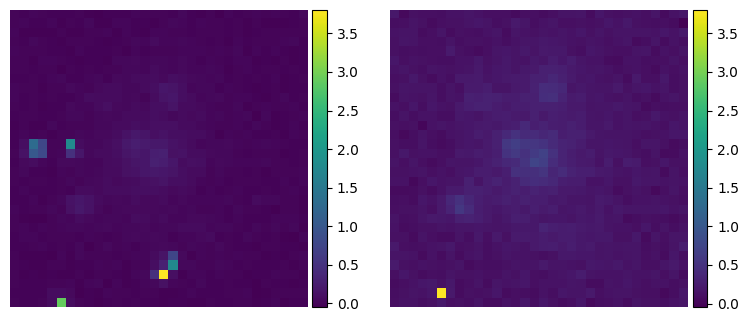

In [176]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))
im = ax1.imshow(data["observation"][0])
divider = make_axes_locatable(ax1)
cax = divider.append_axes('right', size='5%', pad=0.05)
fig.colorbar(im, cax=cax, orientation='vertical')
ax1.axis("off")

ax2.imshow(data["observation"][1])
divider = make_axes_locatable(ax2)
cax = divider.append_axes('right', size='5%', pad=0.05)
fig.colorbar(im, cax=cax, orientation='vertical')
ax2.axis("off")

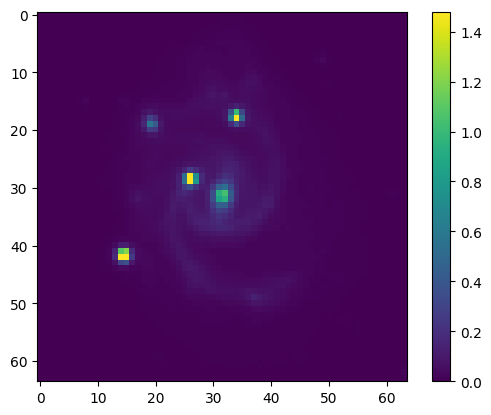

In [177]:
plt.imshow(data["reference"][:])
plt.colorbar()

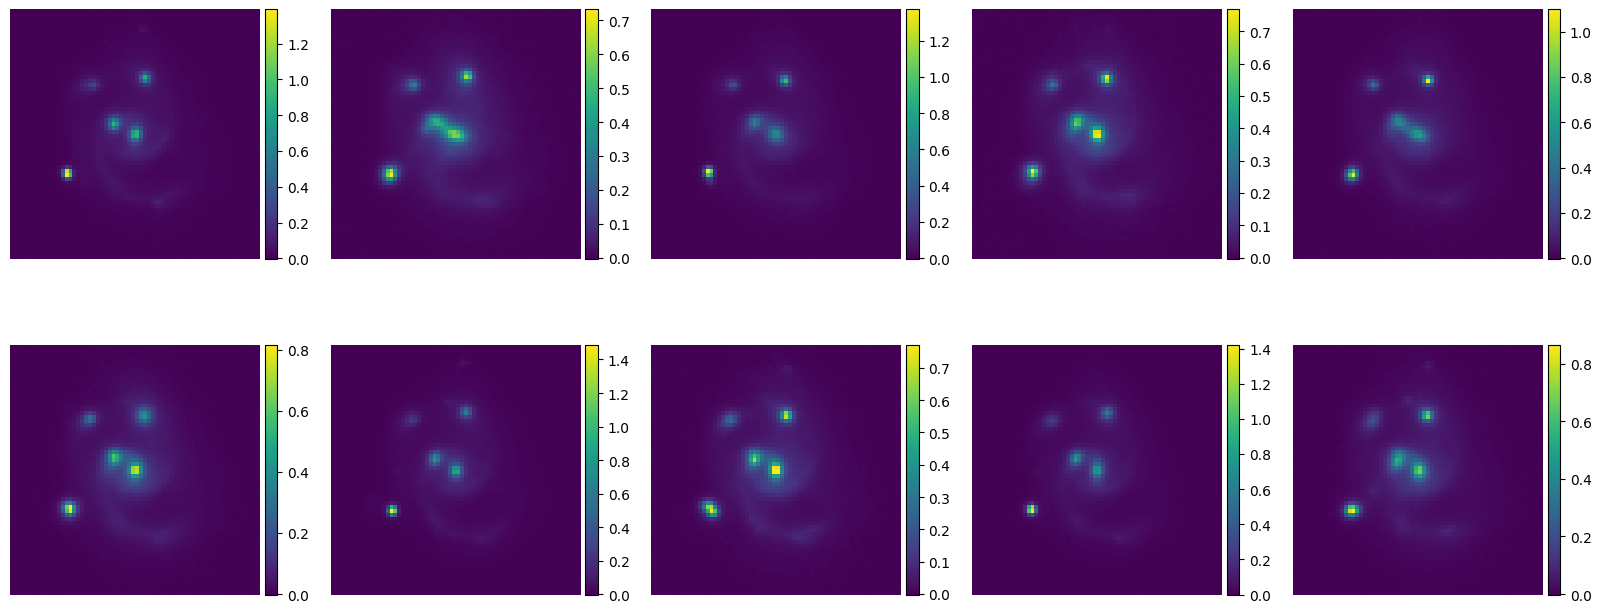

In [178]:
fig, axs = plt.subplots(2, 5, figsize=(20, 8))

for i in range(2):
    for j in range(5):
        k = i * 5 + j
        ax = axs[i, j]
        im = ax.imshow(data["model"][k, 0])
        divider = make_axes_locatable(ax)
        cax = divider.append_axes('right', size='5%', pad=0.05)
        fig.colorbar(im, cax=cax, orientation='vertical')
        ax.axis("off")


# 